# Topic 13: Q-Learning (off-policy TD control)

Q-Learning keeps all of SARSA and changes one term: instead of bootstrapping off the action
it will actually take, `Q(s', a')`, it bootstraps off the BEST next action, `max_a' Q(s', a')`.
That single `max` makes the target the Bellman *optimality* equation, so Q converges toward the
optimal Q* even while the agent behaves with an exploratory epsilon-greedy policy. That split,
**act exploratory, learn greedy**, is what "off-policy" means, and it is what later lets a Deep
Q-Network learn from a replay buffer of old transitions.

## 1. The maze environment (same 5x7 GridWorld as SARSA)

In [1]:
import numpy as np, random
random.seed(0); np.random.seed(0)

class GridWorld:
    def __init__(self): self.x, self.y = 2, 0
    def step(self, a):
        if a==0: self.move_left()
        elif a==1: self.move_up()
        elif a==2: self.move_right()
        elif a==3: self.move_down()
        return (self.x, self.y), -1, self.is_done()
    def move_left(self):
        if self.y==0: pass
        elif self.y==3 and self.x in [0,1,2]: pass
        elif self.y==5 and self.x in [2,3,4]: pass
        else: self.y-=1
    def move_right(self):
        if self.y==1 and self.x in [0,1,2]: pass
        elif self.y==3 and self.x in [2,3,4]: pass
        elif self.y==6: pass
        else: self.y+=1
    def move_up(self):
        if self.x==0: pass
        elif self.x==3 and self.y==2: pass
        else: self.x-=1
    def move_down(self):
        if self.x==4: pass
        elif self.x==1 and self.y==4: pass
        else: self.x+=1
    def is_done(self): return self.x==4 and self.y==6
    def reset(self): self.x, self.y = 0, 0; return (self.x, self.y)

## 2. The Q-learning agent

Only `update` differs from SARSA: `np.max(...)` over the next state's actions, and it needs no next action, so the loop is simpler.

In [2]:
class QLearningAgent:
    def __init__(self):
        self.q_table = np.zeros((5, 7, 4))
        self.eps = 0.9
        self.alpha = 0.1
        self.gamma = 0.9

    def select_action(self, s):              # eps-greedy behavior policy
        x, y = s
        if random.random() < self.eps:
            return random.randint(0, 3)
        return int(np.argmax(self.q_table[x, y, :]))

    def update(self, s, a, r, s_prime, done):
        # Off-policy: bootstrap off the BEST next action, max over a'.
        x, y = s
        x2, y2 = s_prime
        target = r + (0.0 if done else self.gamma * np.max(self.q_table[x2, y2, :]))
        self.q_table[x, y, a] += self.alpha * (target - self.q_table[x, y, a])

    def anneal_eps(self):
        self.eps = max(self.eps - 0.03, 0.1)

In [3]:
random.seed(0); np.random.seed(0)
env = GridWorld()
agent = QLearningAgent()
for n_epi in range(3000):
    s = env.reset()
    done = False
    while not done:
        a = agent.select_action(s)          # choose action for THIS step only
        s_prime, r, done = env.step(a)
        agent.update(s, a, r, s_prime, done)  # no next action needed
        s = s_prime
    agent.anneal_eps()

policy = np.argmax(agent.q_table, axis=2)
s = (0, 0); path = [s]
for _ in range(60):
    if s == (4, 6): break
    a = int(np.argmax(agent.q_table[s[0], s[1], :])); env.x, env.y = s
    s, _, _ = env.step(a); path.append(s)
print("greedy path length:", len(path) - 1, "| reached goal:", s == (4, 6))

greedy path length: 14 | reached goal: True


## 3. On-policy vs off-policy: the cliff-walking example

The maze hides the difference. On the classic cliff (4x12; the bottom edge is a -100 cliff that resets you), SARSA and Q-learning learn **different** greedy policies: SARSA a safe detour, Q-learning the optimal edge-hugging path.

In [4]:
ROWS, COLS = 4, 12
START, GOAL = (3, 0), (3, 11)
CLIFF = {(3, c) for c in range(1, 11)}
MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]      # up, down, left, right

def cliff_step(s, a):
    r = min(max(s[0] + MOVES[a][0], 0), ROWS - 1)
    c = min(max(s[1] + MOVES[a][1], 0), COLS - 1)
    if (r, c) in CLIFF:
        return START, -100, False
    return (r, c), -1, ((r, c) == GOAL)

def eps_greedy(Q, s, eps):
    if random.random() < eps:
        return random.randint(0, 3)
    return int(np.argmax(Q[s[0], s[1]]))

def run_cliff(method, episodes=500, eps=0.1, alpha=0.5, seed=0):
    random.seed(seed); np.random.seed(seed)
    Q = np.zeros((ROWS, COLS, 4)); rewards = []
    for _ in range(episodes):
        s = START; a = eps_greedy(Q, s, eps); done = False; total = 0; t = 0
        while not done and t < 400:
            ns, r, done = cliff_step(s, a); total += r; t += 1
            if method == "sarsa":
                na = eps_greedy(Q, ns, eps)
                tgt = r + (0 if done else Q[ns[0], ns[1], na])
                Q[s[0], s[1], a] += alpha * (tgt - Q[s[0], s[1], a]); s, a = ns, na
            else:                                # q-learning
                tgt = r + (0 if done else np.max(Q[ns[0], ns[1]]))
                Q[s[0], s[1], a] += alpha * (tgt - Q[s[0], s[1], a])
                s = ns; a = eps_greedy(Q, s, eps)
        rewards.append(total)
    return Q, np.array(rewards)

def greedy_len(Q):
    s = START
    for n in range(60):
        if s == GOAL: return n
        s = cliff_step(s, int(np.argmax(Q[s[0], s[1]])))[0]
    return None

Qs, _ = run_cliff("sarsa"); Qq, _ = run_cliff("qlearn")
print("SARSA      greedy path length:", greedy_len(Qs), "(safe detour)")
print("Q-learning greedy path length:", greedy_len(Qq), "(optimal, hugs the cliff)")

# average online reward over 30 runs
sarsa = np.mean([run_cliff("sarsa", seed=i)[1] for i in range(30)], axis=0)
qlearn = np.mean([run_cliff("qlearn", seed=i)[1] for i in range(30)], axis=0)
print("final online reward  SARSA=%.0f  Q-learning=%.0f" % (sarsa[-50:].mean(), qlearn[-50:].mean()))

SARSA      greedy path length: 17 (safe detour)
Q-learning greedy path length: 13 (optimal, hugs the cliff)


final online reward  SARSA=-26  Q-learning=-52


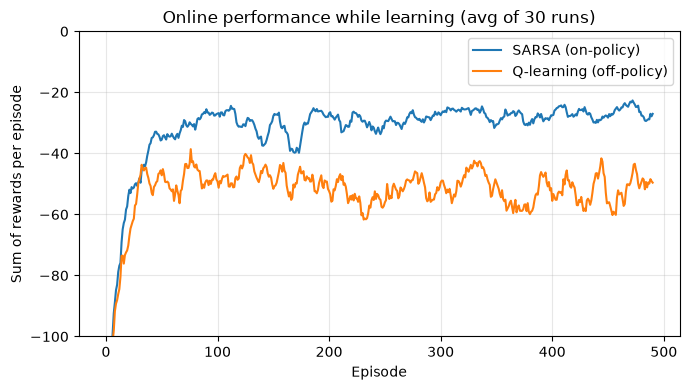

In [5]:
import matplotlib.pyplot as plt
def smooth(x, k=10): return np.convolve(x, np.ones(k)/k, mode="valid")
plt.figure(figsize=(7, 4))
plt.plot(smooth(sarsa), label="SARSA (on-policy)")
plt.plot(smooth(qlearn), label="Q-learning (off-policy)")
plt.ylim(-100, 0); plt.xlabel("Episode"); plt.ylabel("Sum of rewards per episode")
plt.title("Online performance while learning (avg of 30 runs)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

SARSA earns more reward **while learning**, even though Q-learning's greedy policy is optimal: Q-learning walks the cliff edge and its exploration keeps knocking it off. Anneal epsilon to 0 and both converge to the optimal path.

## Try it
- Replace `np.max(...)` with `Q[ns[0], ns[1], na]` (choosing `na` first) and you are back to SARSA, watch the greedy cliff path move up to the safe detour.
- Next topic: swap the Q-table for a neural network `Q(s, a; theta)` and this exact update becomes the DQN loss.